Top 15 genes by adjusted p-value:
       GeneID  Symbol          padj  log2FoldChange  \
0        1116  CHI3L1  1.160000e-58       -6.253504   
1        4314    MMP3  6.080000e-49       -6.716375   
2        4312    MMP1  3.160000e-43       -5.378825   
3       57214   CEMIP  3.950000e-43       -3.926855   
4        7291  TWIST1  6.130000e-42       -4.062901   
5   100288077  WTAPP1  2.390000e-39       -5.134421   
6      199675  MCEMP1  1.660000e-37       -5.325744   
7        6373  CXCL11  7.580000e-35       -4.841309   
8        3502   IGHG3  4.180000e-32       -4.827739   
9       79931   TNIP3  4.320000e-30       -3.395268   
10       8547    FCN3  6.970000e-30       -3.680704   
11       3772  KCNJ15  3.130000e-29       -4.018959   
12       4319   MMP10  6.580000e-29       -4.739183   
13        343    AQP8  1.180000e-28        6.700636   
14     115908  CTHRC1  3.720000e-28       -2.893599   

                                          Description  
0                            

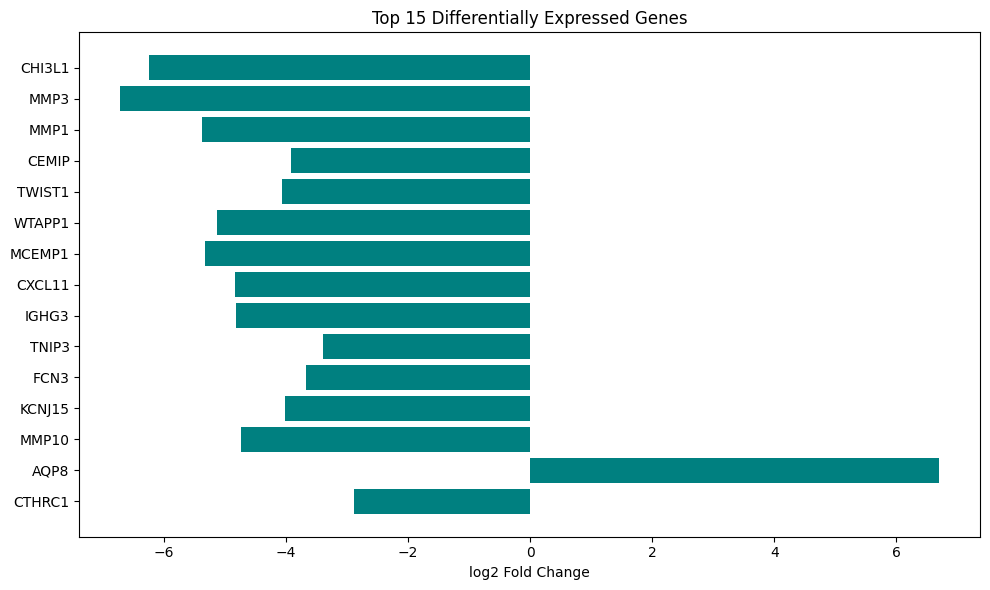

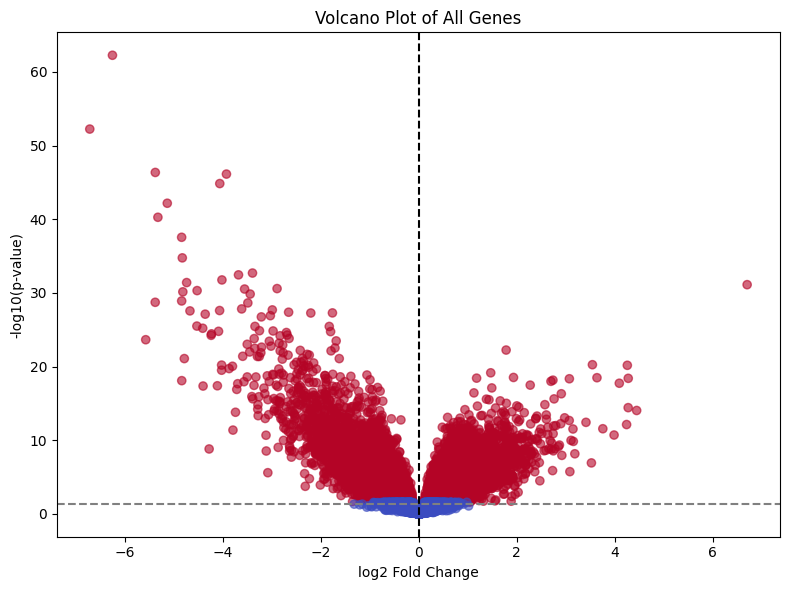

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


file_path = "GSE83687_control_vs_ulcerative_colitis/GSE83687.top.table.tsv"
df = pd.read_csv(file_path, sep="\t")

# Check and sort by padj (adjusted p-value) ---
df = df.dropna(subset=["padj"])  # remove NA padj
df_top15 = df.sort_values("padj").head(15)


print("Top 15 genes by adjusted p-value:")
print(df_top15[["GeneID", "Symbol", "padj", "log2FoldChange", "Description"]])

#  Plot 1 – Barplot of log2FoldChange for top genes ---
plt.figure(figsize=(10, 6))
plt.barh(df_top15["Symbol"], df_top15["log2FoldChange"], color="teal")
plt.gca().invert_yaxis()
plt.xlabel("log2 Fold Change")
plt.title("Top 15 Differentially Expressed Genes")
plt.tight_layout()
plt.show()

# Plot 2 – Volcano plot (full dataset) ---
plt.figure(figsize=(8, 6))
plt.scatter(df["log2FoldChange"], -np.log10(df["pvalue"]), 
            c=(df["padj"] < 0.05), cmap="coolwarm", alpha=0.6)
plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot of All Genes")
plt.axhline(-np.log10(0.05), color="grey", linestyle="--")
plt.axvline(0, color="black", linestyle="--")
plt.tight_layout()
plt.show()



Top enrichment terms:
  source                                     name   p_value
0  GO:CC                     extracellular matrix  0.000083
1  GO:CC         external encapsulating structure  0.000084
2   REAC  Activation of Matrix Metalloproteinases  0.001599
3  GO:BP               collagen catabolic process  0.003488
4  GO:BP         extracellular matrix disassembly  0.009240
5   REAC                     Collagen degradation  0.011978
6  GO:MF            metalloendopeptidase activity  0.014185
7  GO:CC                           cell periphery  0.020282
8  GO:BP                cellular response to UV-A  0.026146
9  GO:BP                         response to UV-A  0.043214


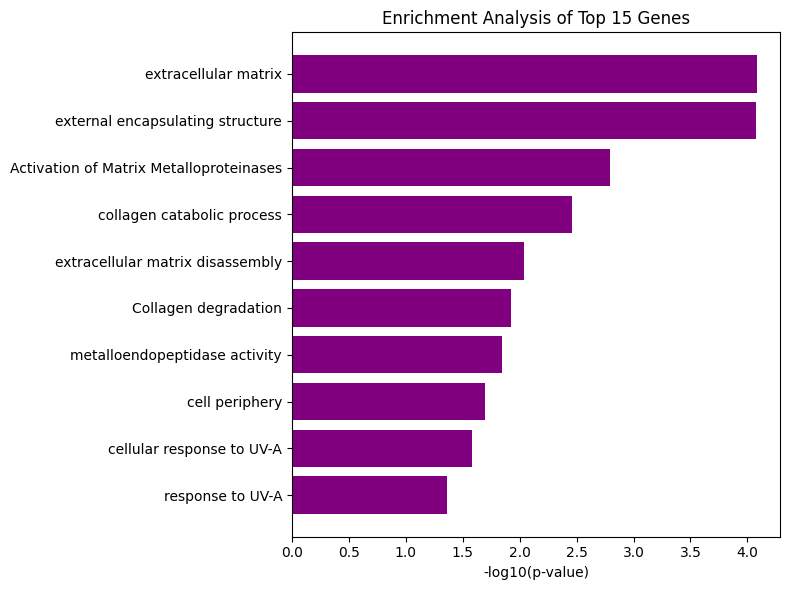

In [5]:
# --- Enrichment analysis for top 15 genes ---
from gprofiler import GProfiler

# Extract gene symbols from your top 15
top_genes = df_top15["Symbol"].dropna().tolist()

# Run enrichment
gp = GProfiler(return_dataframe=True)
enrich = gp.profile(
    organism="hsapiens",  # human
    query=top_genes,
    sources=["GO:BP", "GO:MF", "GO:CC", "KEGG", "REAC"]
)

# Show top results
print("\nTop enrichment terms:")
print(enrich[["source", "name", "p_value"]].head(10))

# Plot top enriched terms
top_terms = enrich.sort_values("p_value").head(10)
plt.figure(figsize=(8, 6))
plt.barh(top_terms["name"], -np.log10(top_terms["p_value"]), color="purple")
plt.gca().invert_yaxis()
plt.xlabel("-log10(p-value)")
plt.title("Enrichment Analysis of Top 15 Genes")
plt.tight_layout()
plt.show()
